In [1]:
from utils_task2 import RedditLinkDataset

dataset = RedditLinkDataset(path="Reddit")
train_loader, val_loader, test_loader = dataset.get_link_loaders(batch_size=512)

Caricamento del macro-grafo originale di Reddit...
Grafo originale: 232965 nodi, 114615892 archi

=== SOTTOGRAFO PER TASK 2 ===
Nodi nel sottografo: 11308
Archi nel sottografo: 3591622

--- STATISTICHE STRUTTURALI DEL GRAFO RIDOTTO ---
Archi positivi (Supervisione) in Train: 1257068
Coppie totali (Pos+Neg) in Val: 359162
Coppie totali (Pos+Neg) in Test: 718324


In [3]:
#iperparametri
lr = 1e-4
num_epochs = 10

Tentativo GCN

In [4]:
import torch
from utils_task2 import GCNLinkPredictor
from utils_task2 import train_loop, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = GCNLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_GCN.pth",
    scaler=scaler,
)




Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.4719 | Loss Val: 0.4522 | Val AUC-ROC: 0.9360 |Val AP: 0.8994 |Val Balanced Acc: 0.8680 |Val F1: 0.8827
--> Modello salvato con Loss Val Migliore: 0.4522


Epoca: 02/10 |Loss Train: 0.4678 | Loss Val: 0.4551 | Val AUC-ROC: 0.9334 |Val AP: 0.8939 |Val Balanced Acc: 0.8701 |Val F1: 0.8843
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 03/10 |Loss Train: 0.4677 | Loss Val: 0.4504 | Val AUC-ROC: 0.9360 |Val AP: 0.8967 |Val Balanced Acc: 0.8684 |Val F1: 0.8827
--> Modello salvato con Loss Val Migliore: 0.4504


Epoca: 04/10 |Loss Train: 0.4674 | Loss Val: 0.4502 | Val AUC-ROC: 0.9360 |Val AP: 0.8999 |Val Balanced Acc: 0.8661 |Val F1: 0.8812
--> Modello salvato con Loss Val Migliore: 0.4502


Epoca: 05/10 |Loss Train: 0.4671 | Loss Val: 0.4529 | Val AUC-ROC: 0.9331 |Val AP: 0.8936 |Val Balanced Acc: 0.8670 |Val F1: 0.8819
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 06/10 |Loss Train: 0.4663 | Loss Val: 0.4616 | Val AUC-ROC: 0.9343 |Val AP: 0.8904 |Val Balanced Acc: 0.8697 |Val F1: 0.8841
--> Nessun miglioramento. Contatore di pazienza: 2/5


Epoca: 07/10 |Loss Train: 0.4669 | Loss Val: 0.4588 | Val AUC-ROC: 0.9333 |Val AP: 0.8898 |Val Balanced Acc: 0.8705 |Val F1: 0.8847
--> Nessun miglioramento. Contatore di pazienza: 3/5


Epoca: 08/10 |Loss Train: 0.4667 | Loss Val: 0.4574 | Val AUC-ROC: 0.9321 |Val AP: 0.8938 |Val Balanced Acc: 0.8668 |Val F1: 0.8818
--> Nessun miglioramento. Contatore di pazienza: 4/5


Epoca: 09/10 |Loss Train: 0.4674 | Loss Val: 0.4567 | Val AUC-ROC: 0.9340 |Val AP: 0.8951 |Val Balanced Acc: 0.8711 |Val F1: 0.8850
--> Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato. Interruzione dell'addestramento.


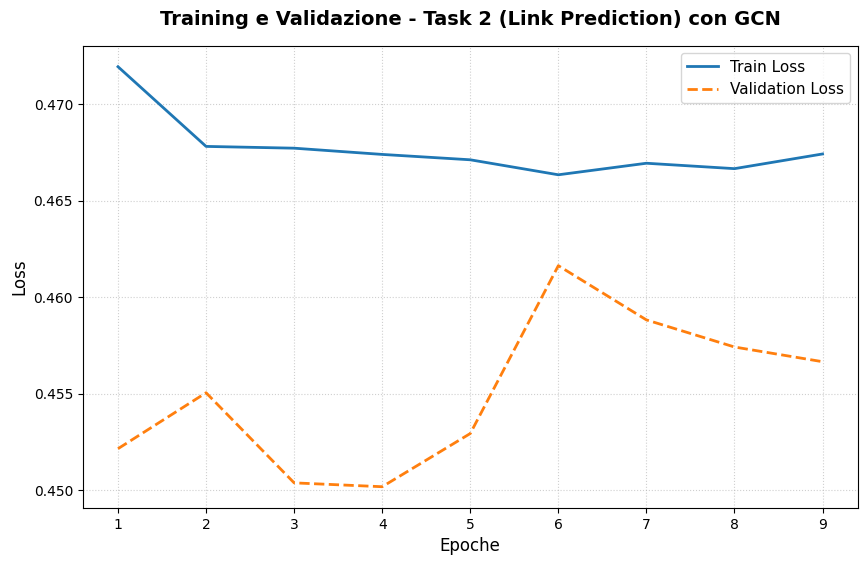

In [5]:
from utils_task1 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con GCN")


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 GCN
-> Test Loss: 0.4578
-> Area Under the ROC Curve (AUC-ROC): 0.9335
-> Average Precision (AP Score): 0.8949
-> Balanced Accuracy: 0.8714
-> F1 Score: 0.8853


[]

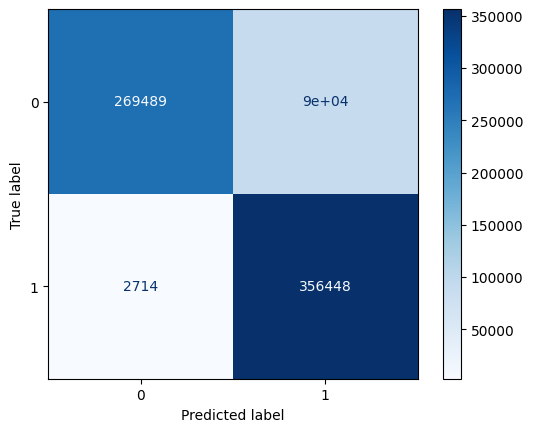

In [6]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 GCN")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

[]

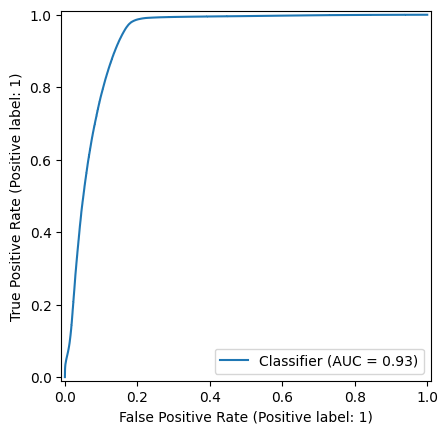

In [7]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()

Tentativo SAGEConv

In [8]:
import torch
from utils_task2 import SAGEConvLinkPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = SAGEConvLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_SAGE.pth",
    scaler=scaler,
)



Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.4606 | Loss Val: 0.4226 | Val AUC-ROC: 0.9666 |Val AP: 0.9615 |Val Balanced Acc: 0.8667 |Val F1: 0.8817
--> Modello salvato con Loss Val Migliore: 0.4226


Epoca: 02/10 |Loss Train: 0.4506 | Loss Val: 0.4191 | Val AUC-ROC: 0.9679 |Val AP: 0.9617 |Val Balanced Acc: 0.8606 |Val F1: 0.8771
--> Modello salvato con Loss Val Migliore: 0.4191


Epoca: 03/10 |Loss Train: 0.4490 | Loss Val: 0.4175 | Val AUC-ROC: 0.9693 |Val AP: 0.9648 |Val Balanced Acc: 0.8645 |Val F1: 0.8800
--> Modello salvato con Loss Val Migliore: 0.4175


Epoca: 04/10 |Loss Train: 0.4484 | Loss Val: 0.4156 | Val AUC-ROC: 0.9689 |Val AP: 0.9647 |Val Balanced Acc: 0.8611 |Val F1: 0.8775
--> Modello salvato con Loss Val Migliore: 0.4156


...

Epoca: 06/10 |Loss Train: 0.4474 | Loss Val: 0.4153 | Val AUC-ROC: 0.9707 |Val AP: 0.9668 |Val Balanced Acc: 0.8595 |Val F1: 0.8763
--> Modello salvato con Loss Val Migliore: 0.4153


Epoca: 07/10 |Loss Train: 0.4475 | Loss Val: 0.4168 | Val AUC-ROC: 0.9703 |Val AP: 0.9669 |Val Balanced Acc: 0.8565 |Val F1: 0.8738
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 08/10 |Loss Train: 0.4471 | Loss Val: 0.4159 | Val AUC-ROC: 0.9702 |Val AP: 0.9659 |Val Balanced Acc: 0.8599 |Val F1: 0.8765
--> Nessun miglioramento. Contatore di pazienza: 2/5


Epoca: 09/10 |Loss Train: 0.4468 | Loss Val: 0.4183 | Val AUC-ROC: 0.9707 |Val AP: 0.9673 |Val Balanced Acc: 0.8581 |Val F1: 0.8750
--> Nessun miglioramento. Contatore di pazienza: 3/5


Epoca: 10/10 |Loss Train: 0.4471 | Loss Val: 0.4187 | Val AUC-ROC: 0.9705 |Val AP: 0.9669 |Val Balanced Acc: 0.8532 |Val F1: 0.8713
--> Nessun miglioramento. Contatore di pazienza: 4/5


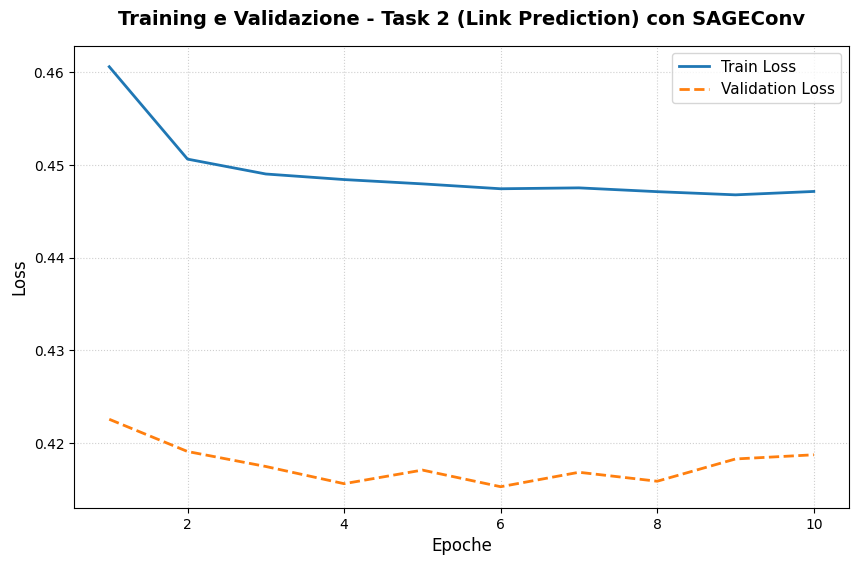

In [9]:
from utils_task1 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con SAGEConv")


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 SAGEConv
-> Test Loss: 0.4192
-> Area Under the ROC Curve (AUC-ROC): 0.9703
-> Average Precision (AP Score): 0.9668
-> Balanced Accuracy: 0.8535
-> F1 Score: 0.8716


[]

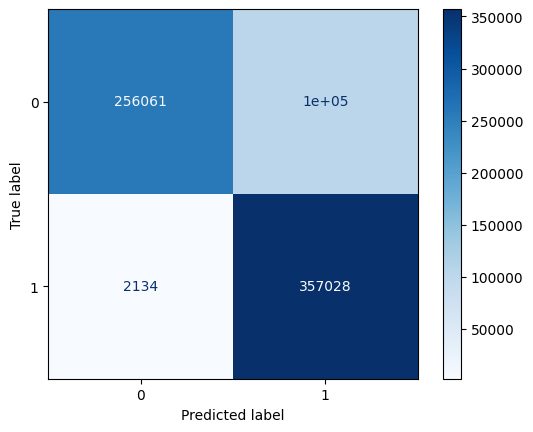

In [10]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 SAGEConv")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

[]

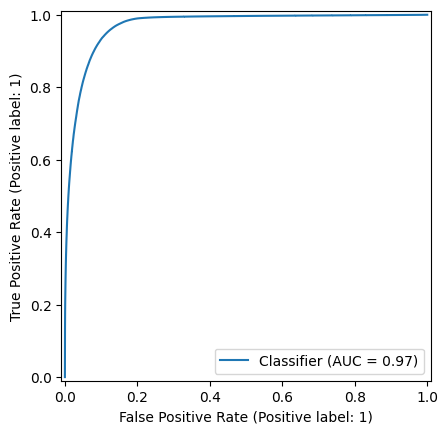

In [11]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()

Tentativo GAT

In [12]:
import torch
from utils_task2 import GATLinkPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = GATLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_GAT.pth",
    scaler=scaler,
)



Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.4689 | Loss Val: 0.4381 | Val AUC-ROC: 0.9539 |Val AP: 0.9426 |Val Balanced Acc: 0.8624 |Val F1: 0.8784
--> Modello salvato con Loss Val Migliore: 0.4381


Epoca: 02/10 |Loss Train: 0.4607 | Loss Val: 0.4345 | Val AUC-ROC: 0.9574 |Val AP: 0.9493 |Val Balanced Acc: 0.8603 |Val F1: 0.8768
--> Modello salvato con Loss Val Migliore: 0.4345


Epoca: 03/10 |Loss Train: 0.4593 | Loss Val: 0.4299 | Val AUC-ROC: 0.9581 |Val AP: 0.9505 |Val Balanced Acc: 0.8670 |Val F1: 0.8819
--> Modello salvato con Loss Val Migliore: 0.4299


Epoca: 04/10 |Loss Train: 0.4586 | Loss Val: 0.4290 | Val AUC-ROC: 0.9586 |Val AP: 0.9516 |Val Balanced Acc: 0.8695 |Val F1: 0.8838
--> Modello salvato con Loss Val Migliore: 0.4290


...

Epoca: 06/10 |Loss Train: 0.4575 | Loss Val: 0.4291 | Val AUC-ROC: 0.9608 |Val AP: 0.9539 |Val Balanced Acc: 0.8645 |Val F1: 0.8800
--> Nessun miglioramento. Contatore di pazienza: 2/5


Epoca: 07/10 |Loss Train: 0.4569 | Loss Val: 0.4281 | Val AUC-ROC: 0.9601 |Val AP: 0.9534 |Val Balanced Acc: 0.8664 |Val F1: 0.8815
--> Modello salvato con Loss Val Migliore: 0.4281


Epoca: 08/10 |Loss Train: 0.4571 | Loss Val: 0.4277 | Val AUC-ROC: 0.9606 |Val AP: 0.9541 |Val Balanced Acc: 0.8665 |Val F1: 0.8815
--> Modello salvato con Loss Val Migliore: 0.4277


Epoca: 09/10 |Loss Train: 0.4564 | Loss Val: 0.4299 | Val AUC-ROC: 0.9595 |Val AP: 0.9504 |Val Balanced Acc: 0.8691 |Val F1: 0.8834
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 10/10 |Loss Train: 0.4560 | Loss Val: 0.4271 | Val AUC-ROC: 0.9611 |Val AP: 0.9546 |Val Balanced Acc: 0.8651 |Val F1: 0.8804
--> Modello salvato con Loss Val Migliore: 0.4271


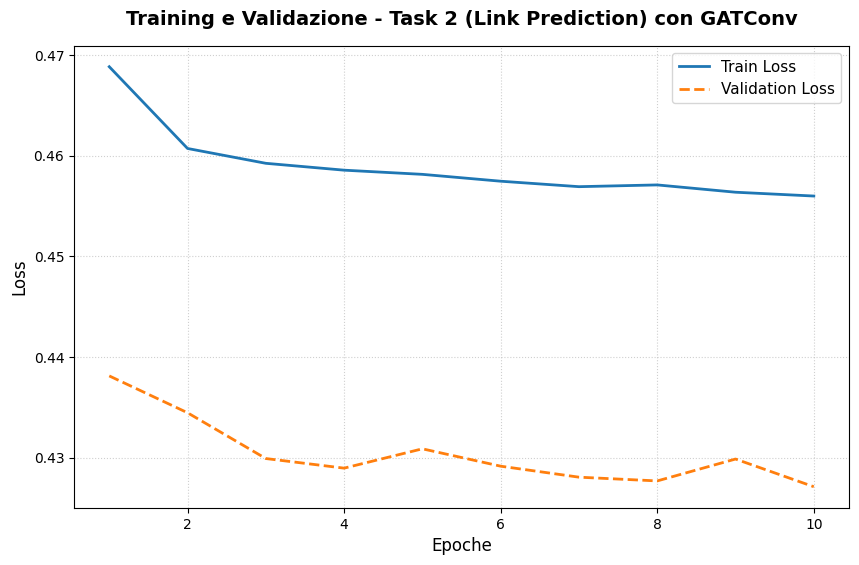

In [13]:
from utils_task1 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con GATConv")


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 GATConv
-> Test Loss: 0.4276
-> Area Under the ROC Curve (AUC-ROC): 0.9607
-> Average Precision (AP Score): 0.9541
-> Balanced Accuracy: 0.8657
-> F1 Score: 0.8809


[]

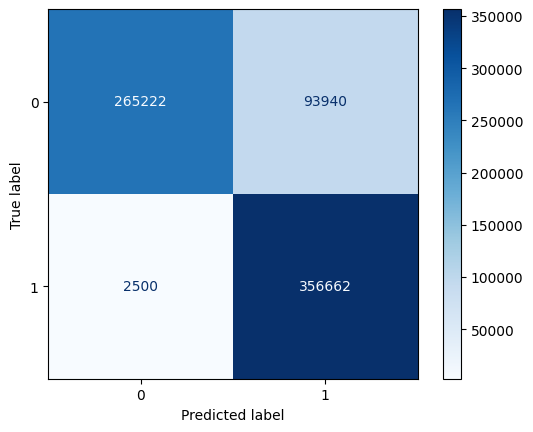

In [14]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 GATConv")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

[]

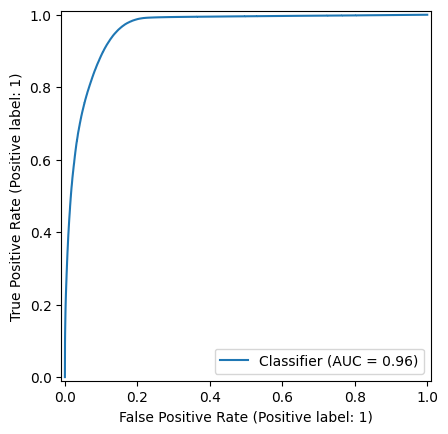

In [15]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()